# Bayes-Net Models: Jern et al. (2014) Replication

This notebook defines the replication's belief-updating models as explicit
Bayesian networks (pgmpy), fits them to participants' ratings, and compares
them. It is organized in six parts:

1. **Modeling** — network definition and construction, exact inference,
   and the fitting and plotting infrastructure shared by everything below.
2. **Point-mass reliability models** — Model A (chart prior) and Model C
   (participant-level empirical prior): one inferred quantity, the
   reliability `theta`. Fits, diagnostics, figures, comparison.
3. **Beta reliability models** — Model B (chart prior) and Model D
   (empirical prior): a Beta(a, b) prior over `theta`. Fits, figures, the
   identification ridge, an exact equivalence result, what the ridge says
   about expected reliability, and what design would identify it.
4. **Response drift** — all four models with a condition-independent
   additive response drift, estimated either from Control alone or jointly,
   giving a 3 regimes x 4 models comparison.
5. **Interpretation** of Parts 2-4.
6. **Two-stage model** — participants endorse one of the two tests and
   update on that test alone, with an endorsement model for stage 1.

## The network

Nodes:

- `Theta`: reliability of the tests, discretized over a grid of candidate
  values. Any prior shape can be supplied as a weight vector over the slots;
  a point mass is a single-slot grid.
- `D`: the patient's true disease, one of L1/L2 (Allozedic) or Y1/Y2
  (Hypozedic).
- `C`: the disease class (A = Allozedic, H = Hypozedic), a deterministic
  function of `D`.
- `T1`, `T2`: the two test results shown to participants.

The graph differs by condition in where the tests attach:

- Polarization & Moderation (tests name a *disease*):
  `Theta -> T1 <- D -> C`, `Theta -> T2 <- D`, with
  P(T = t | D, theta) = theta if t = D, else (1 - theta)/3.
- Control (tests name a *class*): `Theta -> T1 <- C <- D`,
  `Theta -> T2 <- C`, with P(T = t | C, theta) = theta_C if t = C, else
  1 - theta_C, where theta_C = theta + (1 - theta)/3 is the probability
  that a test with disease-level accuracy theta names a disease in the
  true class (the true disease, or the other disease of the same class).
  The class screens off the disease (T ⊥ D | C).

**Lower bound on theta.** A disease-level test names one of four diseases,
so a test answering at random is right a quarter of the time: theta = 0.25
is the uninformative point (beliefs do not move) and theta < 0.25 would
make the tests anti-informative, which the instructions ("fairly accurate
but sometimes give false results") do not support. All fitting restricts
theta to [0.25, 1). Under the derived class accuracy, theta in [0.25, 1]
maps onto theta_C in [0.5, 1], so the class-level test's own chance floor
is respected automatically by the same parameter.

**No instructed reliability.** Participants were never shown a numerical
reliability (`materials/stimuli/JernRep-ExperimentScreens-Pilot.pdf`); the
0.7 used by the R pipeline is Jern et al.'s modeling assumption. Here theta
is always a fitted quantity. The R pipeline's models are reproduced exactly
by these networks in `JernRep-BayesNetModels-Full.py`; that validation is
omitted here.

# Part 1: Modeling

In [1]:
## Setup
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1 import make_axes_locatable
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination
from pgmpy.models import DiscreteBayesianNetwork
from scipy import stats
from scipy.optimize import brentq, minimize, minimize_scalar

## Outcome spaces
DISEASES = ["L1", "L2", "Y1", "Y2"]
CLASSES = ["A", "H"]  ## A = Allozedic, H = Hypozedic
CLASS_OF = {"L1": "A", "L2": "A", "Y1": "H", "Y2": "H"}

## Prior over the four diseases implied by the baseline frequency chart
CHART_PRIOR = {"L1": 0.01, "L2": 0.35, "Y1": 0.40, "Y2": 0.24}

## Reliability support. THETA_GRID (the fitting support) starts at the chance
## level of a four-outcome test; THETA_GRID_FULL is the unconstrained (0, 1)
## support, used only to show what the constraint changes.
THETA_FLOOR = 0.25
THETA_GRID = np.linspace(THETA_FLOOR, 0.999, 2000)
THETA_GRID_FULL = np.linspace(0.001, 0.999, 2000)

## Test results observed in each condition (T1 then T2)
POLARIZATION_TESTS = {"T1": "Y1", "T2": "L1"}
MODERATION_TESTS = {"T1": "Y2", "T2": "L2"}
CONTROL_TESTS = {"T1": "H", "T2": "A"}

DATA_DIR = next(
    d / "data" / "processed"
    for d in [Path.cwd(), Path.cwd().parent]
    if (d / "data" / "processed").is_dir()
)

/Users/kangke/projects/jern2014-replication/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/kangke/projects/jern2014-replication/.venv/lib/python3.13/site-packages/pgmpy/estimators/__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in v1.3.0. Use `pgmpy.structure_score` instead.
  from .StructureScore import (


## Scale conversion

Participants report beliefs on a -100..+100 slider; the networks operate
purely on probability scale. These helpers convert between the two and are
applied only when reading inputs or reporting outputs.

In [2]:
def to_slider(p):
    """Convert a probability in [0, 1] to the -100..+100 slider scale."""
    return 200 * np.asarray(p) - 100


def from_slider(rating):
    """Convert a -100..+100 slider rating to probability scale."""
    return (np.asarray(rating) + 100) / 200

## Priors as inputs

A theta prior is a `(grid, weights)` pair: candidate reliability values and
a probability weight for each slot. Any shape over the slots is valid; a
point mass is a one-slot grid. Disease priors are dicts over L1/L2/Y1/Y2:
the chart itself, or the chart rescaled so the class totals match a
participant's initial rating while the within-class ratios stay at the
chart's values.

In [3]:
def point_mass_prior(value):
    """Theta prior with all mass on a single reliability value."""
    return np.array([value]), np.array([1.0])


def beta_prior(a, b, grid=THETA_GRID):
    """Beta(a, b) theta prior, discretized (and thereby truncated) to grid."""
    with np.errstate(divide="ignore", invalid="ignore"):  ## degenerate (a, b) -> nan, handled by callers
        weights = stats.beta.pdf(grid, a, b)
        return grid, weights / weights.sum()


def empirical_prior(p_hypo, base=CHART_PRIOR):
    """Disease prior rescaled so the class totals match an observed class-level
    belief, keeping the within-class ratios fixed at the base (chart) values."""
    p_base = sum(base[d] for d in DISEASES if CLASS_OF[d] == "H")
    scale = {"A": (1 - p_hypo) / (1 - p_base), "H": p_hypo / p_base}
    return {d: base[d] * scale[CLASS_OF[d]] for d in DISEASES}

## Network construction

One public function per condition. Polarization and Moderation share the
disease-level graph (they differ only in which test results are observed);
Control attaches the tests to the class node with the derived class-level
accuracy theta_C = theta + (1 - theta)/3.

In [4]:
def class_level_accuracy(theta):
    """Probability that a test with disease-level accuracy theta names a
    disease in the true class: the true disease (theta) or the other disease
    of the same class ((1 - theta) / 3). Maps [0.25, 1] onto [0.5, 1]."""
    theta = np.asarray(theta, dtype=float)
    return theta + (1 - theta) / 3


def _theta_cpd(grid, weights):
    weights = np.asarray(weights, dtype=float)
    return TabularCPD(
        "Theta", len(grid), weights.reshape(-1, 1) / weights.sum(),
        state_names={"Theta": [float(v) for v in grid]},
    )


def _disease_cpds(prior_D):
    p = np.array([prior_D[d] for d in DISEASES], dtype=float)
    cpd_D = TabularCPD("D", 4, (p / p.sum()).reshape(-1, 1), state_names={"D": DISEASES})
    ## C is a deterministic readout of D's class
    cpd_C = TabularCPD(
        "C", 2, [[1.0 if CLASS_OF[d] == c else 0.0 for d in DISEASES] for c in CLASSES],
        evidence=["D"], evidence_card=[4], state_names={"C": CLASSES, "D": DISEASES},
    )
    return cpd_D, cpd_C


def _test_cpd(test, parent, parent_states, grid, accuracy=None):
    """CPD for one test given its parent (D or C) and Theta: the accuracy when
    the result matches the parent's state, the remainder split evenly across
    the other outcomes. Accuracy defaults to theta (disease-level tests)."""
    grid = np.asarray(grid, dtype=float)
    acc = grid if accuracy is None else np.asarray(accuracy, dtype=float)
    k = len(parent_states)
    blocks = []
    for i in range(k):  ## Columns: parent-major blocks of theta slots
        block = np.tile((1 - acc) / (k - 1), (k, 1))
        block[i] = acc
        blocks.append(block)
    return TabularCPD(
        test, k, np.hstack(blocks),
        evidence=[parent, "Theta"], evidence_card=[k, len(grid)],
        state_names={test: parent_states, parent: parent_states,
                     "Theta": [float(v) for v in grid]},
    )


def _make_disease_level_network(prior_D, theta_grid, theta_weights):
    net = DiscreteBayesianNetwork(
        [("D", "C"), ("D", "T1"), ("D", "T2"), ("Theta", "T1"), ("Theta", "T2")]
    )
    net.add_cpds(
        *_disease_cpds(prior_D), _theta_cpd(theta_grid, theta_weights),
        _test_cpd("T1", "D", DISEASES, theta_grid),
        _test_cpd("T2", "D", DISEASES, theta_grid),
    )
    net.check_model()
    return net


def make_polarization_network(prior_D, theta_grid, theta_weights):
    """Polarization condition: tests name diseases (observed: Y1, then L1)."""
    return _make_disease_level_network(prior_D, theta_grid, theta_weights)


def make_moderation_network(prior_D, theta_grid, theta_weights):
    """Moderation condition: tests name diseases (observed: Y2, then L2)."""
    return _make_disease_level_network(prior_D, theta_grid, theta_weights)


def make_control_network(prior_D, theta_grid, theta_weights):
    """Control condition: tests name classes, so they attach to C, not D,
    with the derived class-level accuracy."""
    net = DiscreteBayesianNetwork(
        [("D", "C"), ("C", "T1"), ("C", "T2"), ("Theta", "T1"), ("Theta", "T2")]
    )
    net.add_cpds(
        *_disease_cpds(prior_D), _theta_cpd(theta_grid, theta_weights),
        _test_cpd("T1", "C", CLASSES, theta_grid, class_level_accuracy(theta_grid)),
        _test_cpd("T2", "C", CLASSES, theta_grid, class_level_accuracy(theta_grid)),
    )
    net.check_model()
    return net


NETWORKS = {
    "Polarization": (make_polarization_network, POLARIZATION_TESTS),
    "Moderation": (make_moderation_network, MODERATION_TESTS),
    "Control": (make_control_network, CONTROL_TESTS),
}

## Inference

Exact inference by variable elimination. `predict` returns the class-level
belief before and after the tests plus the disease and theta posteriors;
`final_belief` is the single query that fitting needs.

In [5]:
def _query(infer, variables, evidence=None):
    try:
        return infer.query(variables=variables, evidence=evidence, show_progress=False)
    except TypeError:  ## pgmpy versions without show_progress
        return infer.query(variables=variables, evidence=evidence)


def predict(network, evidence):
    """P(C = Hypozedic) before/after the tests, with D and Theta posteriors."""
    infer = VariableElimination(network)
    prior_C = _query(infer, ["C"])
    post_C = _query(infer, ["C"], evidence)
    post_D = _query(infer, ["D"], evidence)
    post_theta = _query(infer, ["Theta"], evidence)
    return {
        "p_initial": float(prior_C.get_value(C="H")),
        "p_final": float(post_C.get_value(C="H")),
        "p_D": {d: float(post_D.get_value(D=d)) for d in DISEASES},
        "theta_grid": np.array(post_theta.state_names["Theta"], dtype=float),
        "theta_posterior": post_theta.values,
    }


def final_belief(condition, prior_D, theta_prior):
    """P(C = Hypozedic | tests) for one condition's network."""
    make_network, tests = NETWORKS[condition]
    grid, weights = theta_prior
    infer = VariableElimination(make_network(prior_D, grid, weights))
    return float(_query(infer, ["C"], tests).get_value(C="H"))

## Data

In [6]:
obs = pd.read_csv(DATA_DIR / "JernRep-Data-Processed-Full.csv")
emmeans = pd.read_csv(DATA_DIR / "JernRep-Results-Full-MixedModel-EstMeans.csv")
n_obs = len(obs)
cond_order = ["Moderation", "Control", "Polarization"]
chart_initial = float(to_slider(sum(CHART_PRIOR[d] for d in ["Y1", "Y2"])))
mean_initial = obs.groupby("Condition")["Initial"].mean()
mean_final = obs.groupby("Condition")["Final"].mean()

print(f"n = {n_obs} participants (initial ratings below 0 were excluded in data processing)")
print(obs.groupby("Condition")[["Initial", "Final"]].agg(["mean", "std", "count"]).round(2))

n = 251 participants (initial ratings below 0 were excluded in data processing)
             Initial               Final             
                mean    std count   mean    std count
Condition                                            
Control        50.17  22.02    82  43.82  31.41    82
Moderation     51.32  23.24    85  18.64  43.54    85
Polarization   52.94  23.69    84  57.56  27.73    84


## Fitting infrastructure

**Predictions.** For each participant, a network for their condition with
a disease prior that is either the chart (`"chart"`) or the chart rescaled
to their own initial rating (`"empirical"`), queried for the class belief
after the tests and converted to the slider scale. Predictions depend only
on (condition, initial rating), so they are cached per unique pair.

**Likelihood.** Each participant's Final rating is Normal(fitted, sigma),
with one noise SD shared across conditions. Optionally a
condition-independent *response drift* delta is added to the network's
prediction P: fitted = P + delta. The drift is either absent, fixed at a
value supplied by the caller (Part 4 anchors it to Control), or profiled:
given the predictions, the ML delta is the mean residual Final - P. Sigma
is always profiled (sigma^2 = SSE / n). Maximizing the resulting profile
log-likelihood over the reliability parameters is the joint MLE. Sigma and
delta count as parameters in AIC/BIC whenever they are estimated from the
data.

**Reliability.** Point-mass models optimize theta in [0.25, 1) by bounded
scalar search; Beta models optimize (log a, log b) by Nelder-Mead from
several starts, on the truncated grid.

In [7]:
def prior_D_for(prior_type, initial):
    if prior_type == "chart":
        return CHART_PRIOR
    return empirical_prior(float(from_slider(initial)))


def participant_predictions(theta_prior, prior_type, data):
    """Network-predicted final rating (slider scale) for each row of data."""
    conds = data["Condition"].to_numpy()
    initials = data["Initial"].to_numpy()
    keys = list(conds) if prior_type == "chart" else list(zip(conds, initials))
    cache = {}
    for key in set(keys):
        cond, initial = (key, None) if prior_type == "chart" else key
        cache[key] = float(to_slider(final_belief(cond, prior_D_for(prior_type, initial), theta_prior)))
    return np.array([cache[k] for k in keys])


def evaluate(preds, data, delta=None):
    """Profile log-likelihood of the final ratings given network predictions.

    delta: None (rating = prediction), "joint" (delta profiled as the mean
    residual Final - P), or a fixed number.
    """
    finals = data["Final"].to_numpy()
    if delta is None:
        shift = None
    elif isinstance(delta, str):
        shift = float(np.mean(finals - preds))
    else:
        shift = float(delta)
    fitted = preds if shift is None else preds + shift
    resid = finals - fitted
    sigma = float(np.sqrt(np.mean(resid ** 2)))
    return {"logLik": float(np.sum(stats.norm.logpdf(resid, scale=sigma))),
            "sigma": sigma, "delta": shift, "fitted": fitted}


def _extra_params(delta):
    return 0 if delta is None else 1  ## delta estimated from the data


def fit_point_mass(prior_type, delta=None, data=None):
    """Point-mass reliability by maximum likelihood."""
    data = obs if data is None else data
    def nll(theta):
        return -evaluate(participant_predictions(point_mass_prior(theta), prior_type, data),
                         data, delta)["logLik"]
    result = minimize_scalar(nll, bounds=(THETA_FLOOR, 0.999), method="bounded",
                             options={"xatol": 1e-6})
    preds = participant_predictions(point_mass_prior(result.x), prior_type, data)
    return {"family": "point", "prior": prior_type, "theta": float(result.x), "preds": preds,
            "n_params": 2 + _extra_params(delta), **evaluate(preds, data, delta)}


def fit_beta(prior_type, starts, delta=None, data=None):
    """Beta(a, b) reliability prior by maximum likelihood, multi-start."""
    data = obs if data is None else data
    def nll(log_ab):
        a, b = np.exp(log_ab)
        try:
            value = -evaluate(participant_predictions(beta_prior(a, b), prior_type, data),
                              data, delta)["logLik"]
            return value if np.isfinite(value) else 1e12
        except Exception:
            return 1e12
    runs = []
    for start in starts:
        result = minimize(nll, np.log(start), method="Nelder-Mead",
                          options={"xatol": 1e-5, "fatol": 1e-7, "maxiter": 400})
        a, b = np.exp(result.x)
        runs.append({"start": start, "a": float(a), "b": float(b), "logLik": -result.fun,
                     "r": evidence_ratio(beta_prior(a, b))})
    best = max(runs, key=lambda run: run["logLik"])
    preds = participant_predictions(beta_prior(best["a"], best["b"]), prior_type, data)
    return {"family": "beta", "prior": prior_type, "a": best["a"], "b": best["b"], "r": best["r"],
            "runs": runs, "preds": preds, "n_params": 3 + _extra_params(delta),
            **evaluate(preds, data, delta)}


def evidence_ratio(theta_prior):
    """r = E[theta (1 - theta)] / E[(1 - theta)^2]: the only feature of a
    theta prior that a conflicting test pair can see (Part 3)."""
    grid, weights = theta_prior
    w = np.asarray(weights, dtype=float) / np.sum(weights)
    return float(np.sum(w * grid * (1 - grid)) / np.sum(w * (1 - grid) ** 2))


def prior_moments(theta_prior):
    grid, w = theta_prior[0], theta_prior[1] / theta_prior[1].sum()
    mean = float(np.sum(w * grid))
    return mean, float(np.sqrt(np.sum(w * (grid - mean) ** 2)))


def fit_stats(loglik, n_params):
    return {"logLik": loglik, "AIC": 2 * n_params - 2 * loglik,
            "BIC": n_params * np.log(n_obs) - 2 * loglik}


def condition_means(values):
    return obs.assign(v=values).groupby("Condition")["v"].mean()


def describe(fit):
    if fit["family"] == "point":
        est = f"theta = {fit['theta']:.4f}"
    else:
        est = f"a = {fit['a']:.3f}, b = {fit['b']:.3f}, r = {fit['r']:.4f}"
    if fit["delta"] is not None:
        est += f", delta = {fit['delta']:.2f}"
    return est


def report(fit):
    print(f"{describe(fit)}, sigma = {fit['sigma']:.2f}, logLik = {fit['logLik']:.3f}")
    print("  mean fitted final by condition:",
          {c: round(v, 2) for c, v in condition_means(fit["fitted"]).items()})


def report_runs(fit):
    for run in fit["runs"]:
        mean, sd = prior_moments(beta_prior(run["a"], run["b"]))
        print(f"  start {run['start']}: a = {run['a']:7.3f}, b = {run['b']:7.3f}, "
              f"prior mean = {mean:.3f}, sd = {sd:.3f}, r = {run['r']:.4f}, "
              f"logLik = {run['logLik']:.3f}")


def summary_table(entries):
    """entries: list of (name, fit_like, estimate string); fit_like needs
    logLik, sigma, fitted, n_params."""
    rows = [{"Model": name, "Estimate": est, "k": f["n_params"], "sigma": f["sigma"],
             **fit_stats(f["logLik"], f["n_params"])} for name, f, est in entries]
    table = pd.DataFrame(rows).set_index("Model")
    table["dAIC"] = table["AIC"] - table["AIC"].min()
    return table


## Reference model: no update at all (final = initial)
fit_null = {"n_params": 1, **evaluate(obs["Initial"].to_numpy(float), obs)}

## Plotting infrastructure

Two figure types in the style of the repo's result figures
(`JernRep-Figures.qmd`). **Pre/post trajectories**: thin gray lines are
individual participants, the teal line the mixed-model estimated marginal
mean with its 95% CI ribbon, and model trajectories run from the model's
initial belief to the mean of its fitted finals. **Final against initial**:
each participant's final plotted against their initial per condition, with
model curves, an OLS fit to the participants, and marginal distributions
(initials above, finals to the right, with the model-implied finals as a
dark outline).

In [8]:
phases = [0, 1]
initial_grid = np.arange(0, 101, 2)
curve_data = pd.DataFrame({
    "Condition": np.repeat(cond_order, len(initial_grid)),
    "Initial": np.tile(initial_grid, len(cond_order)),
})
SCALE_CAPTION = ("Certainty ratings range from -100 (Less Common Disease Class) to +100 "
                 "(More Common Disease Class); initial ratings below 0 were excluded.")


def trajectory(fit):
    """{condition: (model initial, mean fitted final)} for a fitted model."""
    start = mean_initial if fit["prior"] == "empirical" else pd.Series(chart_initial, index=cond_order)
    end = condition_means(fit["fitted"])
    return {c: (start[c], end[c]) for c in cond_order}


def model_curve(theta_prior, prior_type, delta=None):
    """{condition: fitted final over initial_grid} for a model."""
    preds = participant_predictions(theta_prior, prior_type, curve_data)
    if delta is not None:
        preds = preds + delta
    return {c: preds[(curve_data["Condition"] == c).to_numpy()] for c in cond_order}


def curve_of(fit):
    prior = point_mass_prior(fit["theta"]) if fit["family"] == "point" else beta_prior(fit["a"], fit["b"])
    return model_curve(prior, fit["prior"], fit["delta"])


def plot_prepost(trajectories):
    """trajectories: list of (label, {condition: (initial, final)}, color, linestyle)."""
    fig, axes = plt.subplots(1, 3, figsize=(10.5, 4.6), sharey=True)
    for ax, cond in zip(axes, cond_order):
        sub = obs[obs["Condition"] == cond]
        ax.plot(phases, sub[["Initial", "Final"]].T.to_numpy(), color="gray", alpha=0.05, lw=0.8)
        em = emmeans[emmeans["Condition"] == cond].set_index("Phase")
        ax.fill_between(phases, em.loc[["Initial", "Final"], "lower.CL"],
                        em.loc[["Initial", "Final"], "upper.CL"], color="#3E7C91", alpha=0.15)
        ax.plot(phases, em.loc[["Initial", "Final"], "emmean"], color="#3E7C91", lw=2.4,
                label="Estimated marginal means")
        for label, traj, color, ls in trajectories:
            ax.plot(phases, traj[cond], color=color, lw=1.6, ls=ls, label=label)
        ax.axhline(0, ls=":", color="gray", lw=0.8)
        ax.set_title(cond, fontweight="bold", fontsize=11)
        ax.set_xticks(phases, ["Initial", "Final"])
        ax.set_xlim(-0.25, 1.25)
    axes[0].set_ylim(-100, 100)
    axes[0].set_yticks(range(-100, 101, 50))
    axes[0].set_ylabel("Certainty Rating")
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=3, frameon=False, fontsize=9,
               bbox_to_anchor=(0.5, 0.03))
    fig.text(0.01, 0.005, SCALE_CAPTION, fontsize=7.5, color="gray")
    fig.subplots_adjust(bottom=0.27, left=0.07, right=0.98, top=0.9)
    return fig


def plot_scatter(curves, margin_fitted, margin_label):
    """curves: list of (label, {condition: y over initial_grid}, color, linestyle);
    margin_fitted: fitted finals per row of obs, drawn as an outline on the right margin."""
    bins_initial = np.arange(0, 101, 10)
    bins_final = np.arange(-100, 101, 10)
    fig, axes = plt.subplots(1, 3, figsize=(11.5, 5.4), sharey=True)
    for ax, cond in zip(axes, cond_order):
        sub = obs[obs["Condition"] == cond]
        in_cond = (obs["Condition"] == cond).to_numpy()
        ax.scatter(sub["Initial"], sub["Final"], s=14, color="#3E7C91", alpha=0.45,
                   linewidths=0, label="Participants")
        ols = stats.linregress(sub["Initial"], sub["Final"])
        ax.plot([0, 100], [ols.intercept, ols.intercept + 100 * ols.slope], color="#3E7C91",
                lw=1.2, ls="--", label="OLS fit to participants")
        ax.plot([0, 100], [0, 100], ls=":", color="gray", lw=1, label="No change")
        for label, curve, color, ls in curves:
            ax.plot(initial_grid, curve[cond], color=color, lw=1.7, ls=ls, label=label)
        ax.axhline(0, ls=":", color="gray", lw=0.6)
        ax.set_xlim(-3, 103)
        ax.set_xlabel("Initial rating")
        divider = make_axes_locatable(ax)
        ax_top = divider.append_axes("top", size="22%", pad=0.05, sharex=ax)
        ax_right = divider.append_axes("right", size="22%", pad=0.05, sharey=ax)
        ax_top.hist(sub["Initial"], bins=bins_initial, color="#3E7C91", alpha=0.55)
        ax_right.hist(sub["Final"], bins=bins_final, color="#3E7C91", alpha=0.55,
                      orientation="horizontal")
        ax_right.hist(margin_fitted[in_cond], bins=bins_final, histtype="step", color="#303030",
                      lw=1.2, orientation="horizontal")
        for marginal in (ax_top, ax_right):
            marginal.axis("off")
        ax_top.set_title(cond, fontweight="bold", fontsize=11)
    axes[0].set_ylim(-100, 100)
    axes[0].set_yticks(range(-100, 101, 50))
    axes[0].set_ylabel("Final rating")
    handles, labels = axes[0].get_legend_handles_labels()
    handles.append(Line2D([], [], color="#303030", lw=1.2))
    labels.append(margin_label)
    fig.legend(handles, labels, loc="lower center", ncol=3, frameon=False, fontsize=8.5,
               bbox_to_anchor=(0.5, 0.03))
    fig.text(0.01, 0.005, SCALE_CAPTION, fontsize=7.5, color="gray")
    fig.subplots_adjust(bottom=0.25, left=0.07, right=0.98, top=0.95)
    return fig

## Diagnostics infrastructure

**Per-condition theta.** The substantive models use one theta for
everyone; refitting theta separately to the Polarization and Moderation
participants (Control is uninformative about theta) checks whether the two
conditions pull it apart. Any drift is held fixed at the shared fit's
value so the comparison isolates theta.

**Reachable envelope.** The prediction is monotone in theta, so each
participant's reachable final ratings run from their no-update value
(theta = 0.25) to the theta -> 1 limit, in which only the two named
diseases survive in proportion to their priors. A final outside that
interval cannot be produced by any reliability — either the participant
moved the wrong way, or past the limit. Under drift the whole envelope
shifts by delta.

In [9]:
def per_condition_thetas(shared_fit):
    """Refit theta per informative condition with the shared fit's drift fixed."""
    delta = shared_fit["delta"]
    out, fitted = {}, shared_fit["fitted"].copy()
    for cond in ["Polarization", "Moderation"]:
        mask = (obs["Condition"] == cond).to_numpy()
        out[cond] = fit_point_mass(shared_fit["prior"], delta=delta, data=obs[mask])
        fitted[mask] = out[cond]["fitted"]
    combined = {"n_params": shared_fit["n_params"] + 1, **evaluate(fitted, obs)}
    combined["delta"] = delta
    combined["logLik"] = float(np.sum(stats.norm.logpdf(obs["Final"].to_numpy() - fitted,
                                                        scale=combined["sigma"])))
    lr = 2 * (combined["logLik"] - shared_fit["logLik"])
    print(f"per-condition theta: " + ", ".join(
        f"{c} = {f['theta']:.4f}" for c, f in out.items()) +
        f" | shared = {shared_fit['theta']:.4f}; logLik {shared_fit['logLik']:.2f} -> "
        f"{combined['logLik']:.2f}, LR = {lr:.2f} on 1 df, p = {stats.chi2.sf(lr, 1):.4f}")
    return out, combined


def envelope_counts(delta=None):
    rows = []
    for cond in ["Polarization", "Moderation"]:
        sub = obs[obs["Condition"] == cond]
        below = above = 0
        for initial, final in zip(sub["Initial"], sub["Final"]):
            prior_D = empirical_prior(float(from_slider(initial)))
            reach = np.array([to_slider(final_belief(cond, prior_D, point_mass_prior(t)))
                              for t in (THETA_FLOOR, 1 - 1e-9)])
            if delta is not None:
                reach = reach + delta
            below += final < reach.min() - 1e-9
            above += final > reach.max() + 1e-9
        rows.append({"Condition": cond, "n": len(sub), "outside": below + above,
                     "share": (below + above) / len(sub), "below": below, "above": above})
    return pd.DataFrame(rows).set_index("Condition")

# Part 2: Point-mass reliability models

| Model | Disease prior | Reliability | Free parameters |
|---|---|---|---|
| A | chart | point mass at theta | theta, sigma |
| C | participant-level empirical | point mass at theta | theta, sigma |

These models infer one variable, the reliability. Under the chart prior
every participant starts at `to_slider(0.64) = 28`, so only final ratings
inform the fit and each condition gets one predicted final. Under the
empirical prior each participant starts from their own rating and the model
is a curve from initial to final. Bayesian updating is nonlinear in the
prior, so this is not the same as using a condition-mean initial rating.

Two structural facts: theta is one population-level parameter (a
per-participant theta with one final rating each would be saturated), and
under any reliability the Control prediction equals the prior exactly (the
conflicting class-level pair gives every disease the same likelihood), so
Polarization and Moderation carry all the information about theta.

## Model A: chart prior

In [10]:
fit_A = fit_point_mass("chart")
report(fit_A)

theta = 0.4214, sigma = 36.62, logLik = -1259.874
  mean fitted final by condition: {'Control': 28.0, 'Moderation': 8.8, 'Polarization': 49.95}


## Model C: participant-level empirical prior

In [11]:
fit_C = fit_point_mass("empirical")
report(fit_C)
print(obs.assign(Fitted=fit_C["fitted"])
         .groupby("Condition")[["Initial", "Final", "Fitted"]].mean().round(2))

theta = 0.4384, sigma = 36.53, logLik = -1259.288
  mean fitted final by condition: {'Control': 50.17, 'Moderation': 35.45, 'Polarization': 69.43}
              Initial  Final  Fitted
Condition                           
Control         50.17  43.82   50.17
Moderation      51.32  18.64   35.45
Polarization    52.94  57.56   69.43


## Diagnostics

In [12]:
print("Model C, theta by condition")
per_cond_C, fit_C_percond = per_condition_thetas(fit_C)

control = obs[obs["Condition"] == "Control"]
lr_control = stats.linregress(control["Initial"], control["Final"])
print(f"\nControl: Final = {lr_control.intercept:.2f} + {lr_control.slope:.3f} * Initial "
      f"(SE {lr_control.stderr:.3f}, r = {lr_control.rvalue:.2f}, n = {len(control)}); "
      f"mean change = {(control['Final'] - control['Initial']).mean():.2f}")

print("\nReachable envelope (empirical prior, no drift):")
envelope_none = envelope_counts()
print(envelope_none.round(2).to_string())

Model C, theta by condition
per-condition theta: Polarization = 0.3204, Moderation = 0.6802 | shared = 0.4384; logLik -1259.29 -> -1251.18, LR = 16.22 on 1 df, p = 0.0001

Control: Final = 9.61 + 0.682 * Initial (SE 0.140, r = 0.48, n = 82); mean change = -6.35

Reachable envelope (empirical prior, no drift):
               n  outside  share  below  above
Condition                                     
Polarization  84       32   0.38     29      3
Moderation    85       45   0.53     30     15


**Reading the diagnostics.** Fitted separately, the two informative
conditions want very different reliabilities, and the Control regression
says why that should not be read as a difference in updating: the slope of
Final on Initial is well below 1 with a negative mean change, so finals
drift down and toward the middle with no evidence at all. That drift
opposes the upward update in Polarization and assists the downward update
in Moderation. The envelope makes the misfit concrete: a large share of
participants in both conditions sit outside anything a single-reliability
model can produce, in Polarization mostly by moving the wrong way, in
Moderation mostly by moving past the perfect-reliability limit. Part 4
takes up the drift; the Moderation overshoot is a different problem (a
cluster that discarded the prior entirely).

## Figures

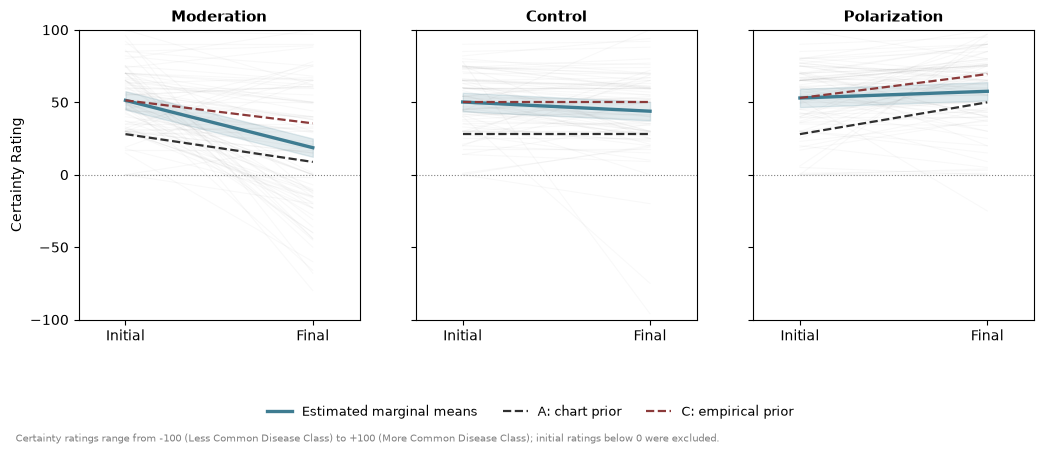

In [13]:
fig = plot_prepost([
    ("A: chart prior", trajectory(fit_A), "#303030", "--"),
    ("C: empirical prior", trajectory(fit_C), "#8B3A3A", "--"),
])

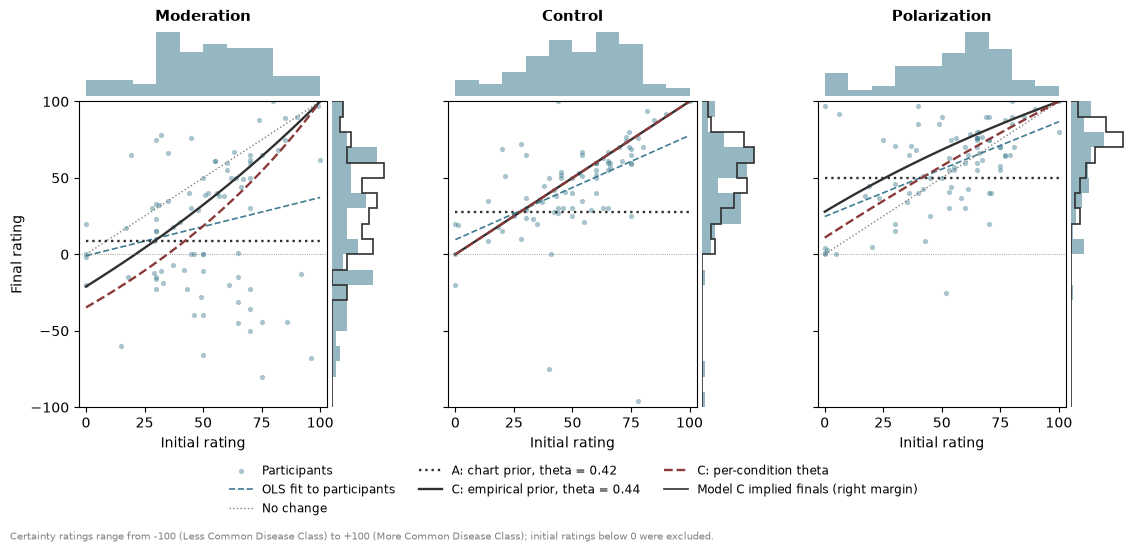

In [14]:
fig = plot_scatter([
    (f"A: chart prior, theta = {fit_A['theta']:.2f}", curve_of(fit_A), "#303030", ":"),
    (f"C: empirical prior, theta = {fit_C['theta']:.2f}", curve_of(fit_C), "#303030", "-"),
    ("C: per-condition theta", {c: (curve_of(per_cond_C[c])[c] if c in per_cond_C
                                    else curve_of(fit_C)[c]) for c in cond_order}, "#8B3A3A", "--"),
], fit_C["fitted"], "Model C implied finals (right margin)")

## Comparison

In [15]:
table_point = summary_table([
    ("Null: no update (final = initial)", fit_null, "-"),
    ("A: chart prior, point theta", fit_A, describe(fit_A)),
    ("C: empirical prior, point theta", fit_C, describe(fit_C)),
    ("C, per-condition theta (diagnostic)", fit_C_percond,
     ", ".join(f"{c[:3]} {f['theta']:.3f}" for c, f in per_cond_C.items())),
])
print(table_point.round(2).to_string())

                                                 Estimate  k  sigma   logLik      AIC      BIC   dAIC
Model                                                                                                
Null: no update (final = initial)                       -  1  39.12 -1276.49  2554.97  2558.50  46.62
A: chart prior, point theta                theta = 0.4214  2  36.62 -1259.87  2523.75  2530.80  15.40
C: empirical prior, point theta            theta = 0.4384  2  36.53 -1259.29  2522.58  2529.63  14.22
C, per-condition theta (diagnostic)  Pol 0.320, Mod 0.680  3  35.37 -1251.18  2508.35  2518.93   0.00


**Reading the comparison.** Any updating model beats no-update decisively:
the tests moved beliefs in the Bayesian direction. Starting participants
from their own ratings (C) removes the glaring misfit of the chart prior —
everyone starting at +28 while they actually started near +50 — yet gains
under one log-likelihood unit, because a single theta is then a compromise
between a Polarization that rose too little and a Moderation that fell too
much.

# Part 3: Beta reliability models

| Model | Disease prior | Reliability | Free parameters |
|---|---|---|---|
| B | chart | Beta(a, b) over [0.25, 1) | a, b, sigma |
| D | participant-level empirical | Beta(a, b) over [0.25, 1) | a, b, sigma |

The observer is now uncertain about the tests' reliability and infers it
jointly with the diagnosis. Each fit is run from several starts; the
multi-start tables are the first sign of the identification problem
analyzed below.

## Model B: chart prior

In [16]:
fit_B = fit_beta("chart", starts=[(3.5, 1.5), (1.0, 1.0), (7.0, 3.0), (0.5, 0.5)])
report_runs(fit_B)
report(fit_B)

  start (3.5, 1.5): a =   0.836, b =   2.201, prior mean = 0.475, sd = 0.167, r = 0.7285, logLik = -1259.874
  start (1.0, 1.0): a =   0.484, b =   1.844, prior mean = 0.481, sd = 0.176, r = 0.7285, logLik = -1259.874
  start (7.0, 3.0): a =   3.014, b =   4.583, prior mean = 0.455, sd = 0.135, r = 0.7285, logLik = -1259.874
  start (0.5, 0.5): a =   0.187, b =   1.551, prior mean = 0.488, sd = 0.184, r = 0.7285, logLik = -1259.874
a = 0.836, b = 2.201, r = 0.7285, sigma = 36.62, logLik = -1259.874
  mean fitted final by condition: {'Control': 28.0, 'Moderation': 8.8, 'Polarization': 49.95}


## Model D: participant-level empirical prior

In [17]:
fit_D = fit_beta("empirical", starts=[(2.0, 2.0), (0.7, 0.4)])
report_runs(fit_D)
report(fit_D)

  start (2.0, 2.0): a =   1.550, b =   2.517, prior mean = 0.493, sd = 0.166, r = 0.7807, logLik = -1259.288
  start (0.7, 0.4): a =   0.456, b =   1.465, prior mean = 0.515, sd = 0.193, r = 0.7807, logLik = -1259.288
a = 1.550, b = 2.517, r = 0.7807, sigma = 36.53, logLik = -1259.288
  mean fitted final by condition: {'Control': 50.17, 'Moderation': 35.45, 'Polarization': 69.43}


## Figures

B lies exactly on A and D on C in both figures.

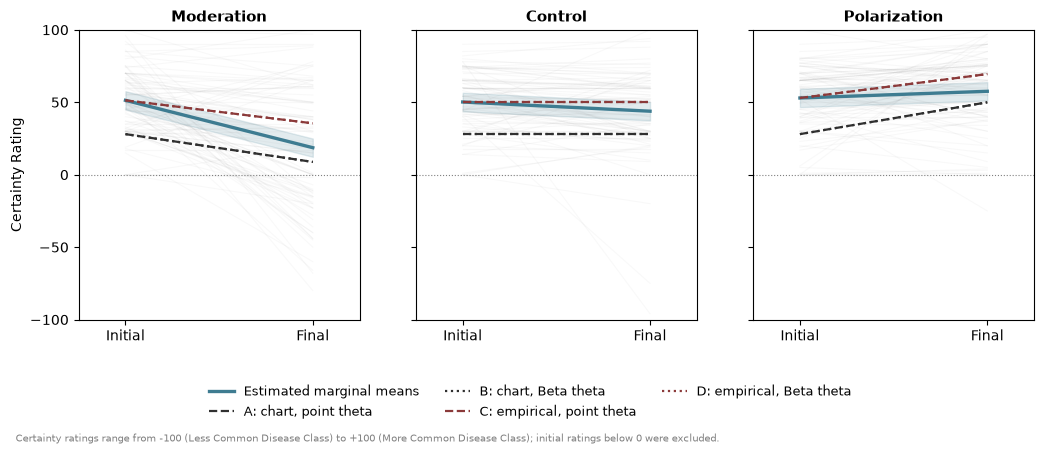

In [18]:
fig = plot_prepost([
    ("A: chart, point theta", trajectory(fit_A), "#303030", "--"),
    ("B: chart, Beta theta", trajectory(fit_B), "#303030", ":"),
    ("C: empirical, point theta", trajectory(fit_C), "#8B3A3A", "--"),
    ("D: empirical, Beta theta", trajectory(fit_D), "#8B3A3A", ":"),
])

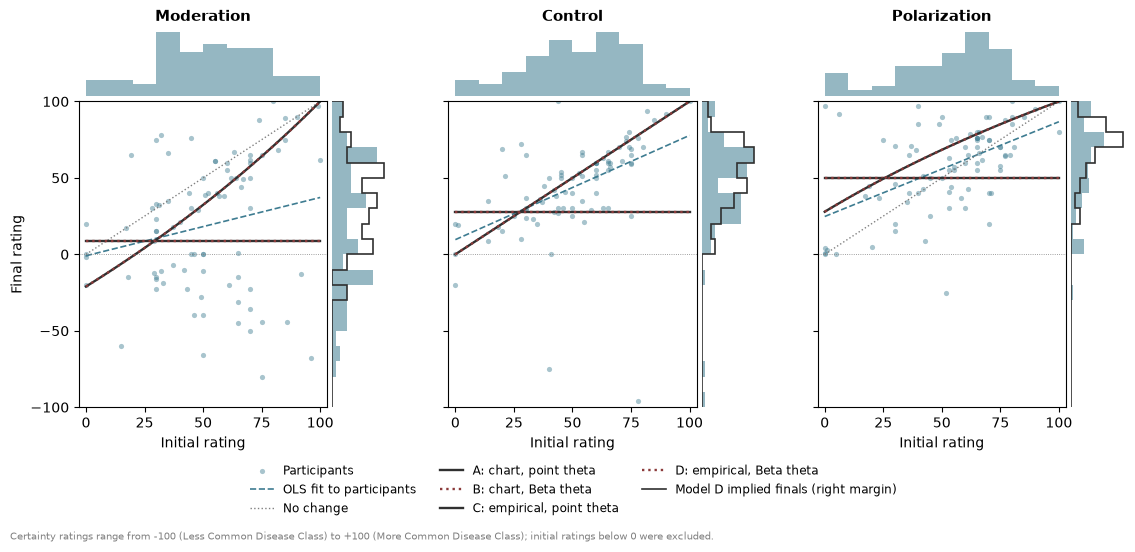

In [19]:
fig = plot_scatter([
    ("A: chart, point theta", curve_of(fit_A), "#303030", "-"),
    ("B: chart, Beta theta", curve_of(fit_B), "#8B3A3A", ":"),
    ("C: empirical, point theta", curve_of(fit_C), "#303030", "-"),
    ("D: empirical, Beta theta", curve_of(fit_D), "#8B3A3A", ":"),
], fit_D["fitted"], "Model D implied finals (right margin)")

## The ridge: (a, b) are not identified

Every start converges to a different (a, b) with the same log-likelihood,
the same predictions, and the same value of one number, r. The ridge is
exact, not an optimizer artifact.

With two *conflicting* disease-level tests, the likelihood of the pair
given disease D is theta (1 - theta) / 3 when D is one of the two named
diseases and ((1 - theta) / 3)^2 otherwise. Averaging over any theta
prior, the posterior over diseases depends on the prior only through

    r = E[theta (1 - theta)] / E[(1 - theta)^2],

and the Control prediction does not depend on theta at all. This holds
for every disease prior. A point mass at theta0 has r = theta0/(1-theta0),
which sweeps every r in [1/3, inf) as theta0 runs over [0.25, 1). So
every theta prior, however spread out, makes exactly the same predictions
as some point mass: B's ridge is the level set r = theta_A/(1-theta_A) and
D's is r = theta_C/(1-theta_C). The theta >= 0.25 bound leaves this
untouched — r is a ratio of expectations of positive functions, bounded by
the extremes of theta/(1-theta) over the support, so restricting the
support restricts r to [1/3, inf) and every attainable r is still attained
by a point mass inside the bound.

In [20]:
for label, point, beta_fit in [("A vs B", fit_A, fit_B), ("C vs D", fit_C, fit_D)]:
    r_point = point["theta"] / (1 - point["theta"])
    print(f"{label}: theta/(1-theta) = {r_point:.4f} | r across Beta starts = "
          f"{[round(run['r'], 4) for run in beta_fit['runs']]} | logLik point = "
          f"{point['logLik']:.3f}, Beta = {beta_fit['logLik']:.3f}")
    assert np.isclose(point["logLik"], beta_fit["logLik"], atol=0.5)

A vs B: theta/(1-theta) = 0.7285 | r across Beta starts = [0.7285, 0.7285, 0.7285, 0.7285] | logLik point = -1259.874, Beta = -1259.874
C vs D: theta/(1-theta) = 0.7807 | r across Beta starts = [0.7807, 0.7807] | logLik point = -1259.288, Beta = -1259.288


## Comparison

In [21]:
table_beta = summary_table([
    ("Null: no update (final = initial)", fit_null, "-"),
    ("A: chart prior, point theta", fit_A, describe(fit_A)),
    ("C: empirical prior, point theta", fit_C, describe(fit_C)),
    ("B: chart prior, Beta theta", fit_B, f"r = {fit_B['r']:.3f} (a, b on a ridge)"),
    ("D: empirical prior, Beta theta", fit_D, f"r = {fit_D['r']:.3f} (a, b on a ridge)"),
])
print(table_beta.round(2).to_string())

                                                      Estimate  k  sigma   logLik      AIC      BIC   dAIC
Model                                                                                                     
Null: no update (final = initial)                            -  1  39.12 -1276.49  2554.97  2558.50  32.40
A: chart prior, point theta                     theta = 0.4214  2  36.62 -1259.87  2523.75  2530.80   1.17
C: empirical prior, point theta                 theta = 0.4384  2  36.53 -1259.29  2522.58  2529.63   0.00
B: chart prior, Beta theta         r = 0.728 (a, b on a ridge)  3  36.62 -1259.87  2525.75  2536.32   3.17
D: empirical prior, Beta theta     r = 0.781 (a, b on a ridge)  3  36.53 -1259.29  2524.58  2535.15   2.00


B reaches exactly A's likelihood and D exactly C's, so AIC and BIC prefer
the point-mass versions purely on parameter count. This is not evidence
that participants held a sharp belief about reliability; it is the design
being unable to distinguish the two.

## What the ridge says about expected reliability

Equivalence does not mean the Beta and the point mass agree about
reliability. Along the ridge the Beta's *mean* is always higher than the
equivalent point mass. For a Beta on all of (0, 1) with a = r (b + 1),

    E[theta] = r (b + 1) / (r (b + 1) + b)  >  r / (1 + r) = theta0,

with equality only as b -> inf and the mean climbing toward 1 as b -> 0.
The mechanism is the weighting inside r: a conflicting pair is evidence
against high reliability, and its (1 - theta)^2 factor discounts
high-theta mass, so a spread prior needs a higher mean to deliver the same
effective evidence weight. Uncertainty about reliability discounts a
conflicting pair by itself — near-certain reliability is incompatible with
a conflict — so the fitted point mass is the *floor* of the mean
reliability beliefs consistent with the data, not an estimate of that mean.

The theta >= 0.25 constraint changes what the ridge admits. On (0, 1) the
ridge runs to near-flat priors, because anti-informative mass below 0.25
can offset near-certain mass close to 1. On [0.25, 1) that trade is
unavailable: below a minimum b the widest priors have r above the target
for *every* a and cannot lie on the ridge at all, so the admissible means
compress toward theta0. The trace below finds `b_min` by solving
r(a -> 0, b) = r on each support and the ridge member at each b by solving
for a.

In [22]:
LOG_A_BRACKET = (np.log(1e-4), np.log(1e4))


def ridge_member(r_target, b, grid):
    """Beta(a, b) on grid with evidence ratio r_target, or None if no a works."""
    f = lambda log_a: evidence_ratio(beta_prior(np.exp(log_a), b, grid)) - r_target
    if f(LOG_A_BRACKET[0]) > 0:
        return None
    return float(np.exp(brentq(f, *LOG_A_BRACKET)))


def trace_ridge(point_fit, label, b_values=(0.05, 0.2, 0.5, 1, 2, 5, 10, 30, 100)):
    r_target = point_fit["theta"] / (1 - point_fit["theta"])
    rows = []
    for name, grid in [("(0, 1)", THETA_GRID_FULL), ("[0.25, 1)", THETA_GRID)]:
        g = lambda log_b: (evidence_ratio(beta_prior(np.exp(LOG_A_BRACKET[0]), np.exp(log_b), grid))
                           - r_target)
        b_min = float(np.exp(brentq(g, np.log(1e-3), np.log(1e3)))) if g(np.log(1e-3)) > 0 else None
        print(f"{label}, support {name}: ridge exists for "
              f"{'b >= %.3f' % b_min if b_min else 'every b'}")
        for b in ([b_min * 1.001] if b_min else []) + list(b_values):
            a = ridge_member(r_target, b, grid)
            mean, sd = prior_moments(beta_prior(a, b, grid)) if a is not None else (np.nan, np.nan)
            rows.append({"support": name, "b": round(b, 3), "a": a, "mean": mean, "sd": sd})
    table = pd.DataFrame(rows)
    print(f"theta0 = {point_fit['theta']:.4f}, r = {r_target:.4f}")
    print(table.pivot(index="b", columns="support", values=["a", "mean", "sd"]).round(3).to_string())
    assert (table.dropna()["mean"] > point_fit["theta"]).all()
    return table


ridge_B = trace_ridge(fit_A, "Model B ridge")
print()
ridge_D = trace_ridge(fit_C, "Model D ridge")

Model B ridge, support (0, 1): ridge exists for every b
Model B ridge, support [0.25, 1): ridge exists for b >= 1.371
theta0 = 0.4214, r = 0.7285
              a             mean               sd          
support  (0, 1) [0.25, 1) (0, 1) [0.25, 1) (0, 1) [0.25, 1)
b                                                          
0.050     0.760       NaN  0.806       NaN  0.273       NaN
0.200     0.871       NaN  0.758       NaN  0.285       NaN
0.500     1.092       NaN  0.677       NaN  0.287       NaN
1.000     1.457       NaN  0.593       NaN  0.264       NaN
1.372       NaN     0.002    NaN     0.493    NaN     0.190
2.000     2.185     0.639  0.522     0.478  0.219     0.172
5.000     4.371     3.375  0.466     0.453  0.155     0.132
10.000    8.013     7.474  0.445     0.441  0.114     0.105
30.000   22.582    22.522  0.429     0.429  0.068     0.067
100.000  73.574    73.574  0.424     0.424  0.037     0.037

Model D ridge, support (0, 1): ridge exists for every b
Model D ridge, su

On (0, 1) the ridge admits means from theta0 up to about 0.8. On
[0.25, 1) it stops at b of about 1.4 (B) or 1.1 (D), where the widest
admissible member has a mean near 0.5 with sd near 0.2. Under the
constraint the data are therefore consistent with mean reliability beliefs
anywhere from the point mass up to roughly 0.5 — much tighter than the
unconstrained range, but still strictly above the point mass.

## What would identify uncertainty about theta

The equivalence is specific to conflicting test pairs. A pair of
*agreeing* tests brings E[theta^2] into the predictions, and by
Cauchy-Schwarz E[theta^2] E[(1 - theta)^2] >= E[theta (1 - theta)]^2 with
equality only for a point mass — so any genuinely uncertain theta prior
predicts strictly stronger updating from two agreeing tests than its
observationally equivalent point mass. Models A and B agree on the
conflicting pair and diverge on an agreeing pair (both tests naming Y1).

In [23]:
agreeing_tests = {"T1": "Y1", "T2": "Y1"}
for label, theta_prior in [("Model A (point mass)", point_mass_prior(fit_A["theta"])),
                           ("Model B (ridge Beta)", beta_prior(fit_B["a"], fit_B["b"]))]:
    net = make_polarization_network(CHART_PRIOR, *theta_prior)
    conflicting = predict(net, POLARIZATION_TESTS)
    agreeing = predict(net, agreeing_tests)
    print(f"{label:<21}: after conflicting pair (Y1, L1) = "
          f"{float(to_slider(conflicting['p_final'])):6.2f}, "
          f"after agreeing pair (Y1, Y1) = {float(to_slider(agreeing['p_final'])):6.2f}")

Model A (point mass) : after conflicting pair (Y1, L1) =  49.95, after agreeing pair (Y1, Y1) =  71.32
Model B (ridge Beta) : after conflicting pair (Y1, L1) =  49.95, after agreeing pair (Y1, Y1) =  80.01


# Part 4: Response drift

Every model so far says that all systematic change from initial to final
rating is produced by the diagnostic evidence and theta:

    Final_i = f(Initial_i, Condition_i, theta) + noise_i

with f the network's prediction. The drift model adds a common term,

    Final_i = f(Initial_i, Condition_i, theta) + delta + noise_i,

where delta is a *condition-independent response drift*: after whatever
Bayesian updating occurs, participants give somewhat higher or lower
final H ratings for reasons not represented by the evidence. It separates
evidence-driven belief change from a general shift in how participants
respond between the two judgments:

    observed change = evidence-driven Bayesian change + response drift + noise.

Three clues point to a downward component. Control should show no
Bayesian change — the symmetric class-level pair leaves P(H | evidence) =
P(H) for every theta, point mass or Beta — yet its mean rating fell from
50.2 to 43.8. Model C over-predicts final H ratings in all three
conditions, with the same negative sign (Control -6.4, Moderation -16.8,
Polarization -11.9). And a downward drift would produce exactly the
per-condition theta split seen in Part 2: in Polarization the Bayesian
update pushes up while drift pushes down, so the observed polarization
looks weaker and theta_P comes out low; in Moderation both push down, so
moderation looks stronger and theta_M comes out high. Without drift,
theta has to absorb everything.

**The key comparison.** Two explanations of the Part 2 asymmetry each add
one parameter to Model C: *condition-specific reliability*
(theta_P, theta_M; evidence is treated as much stronger in Moderation than
Polarization) versus *shared reliability plus drift* (theta, delta; the
same reliability in both conditions, plus a general response shift). Their
AIC comparison is therefore clean.

**Estimation.** The main model estimates theta and delta jointly across all
three conditions by maximum likelihood (given the predictions, the ML delta
is the mean residual). As a validation, delta is instead fixed at the value
Control alone implies — Control predicts zero Bayesian movement, so
delta_Control = mean(Final - Initial) in Control — and only theta is fitted.
If a drift estimated independently of Polarization and Moderation improves
those conditions, the effect is not merely a parameter tuned to their
outcomes. Both regimes are run for all four models; drift acts after the
network, so the equivalence B = A and D = C survives it exactly.

delta is a response drift, not a belief-update parameter: it could be
response-scale drift, anchoring or compression, an order effect, or another
systematic process between the two measurements. Control is what gives
leverage to detect it.

In [24]:
CONTROL_DELTA = float((control["Final"] - control["Initial"]).mean())
print(f"Control-anchored drift: delta_Control = mean(Final - Initial) in Control = {CONTROL_DELTA:.2f}")

fits = {("none", "A"): fit_A, ("none", "B"): fit_B, ("none", "C"): fit_C, ("none", "D"): fit_D}
for regime, delta in [("control", CONTROL_DELTA), ("joint", "joint")]:
    print(f"\n=== drift regime: {regime} ===")
    fits[(regime, "A")] = fit_point_mass("chart", delta=delta)
    fits[(regime, "C")] = fit_point_mass("empirical", delta=delta)
    fits[(regime, "B")] = fit_beta("chart", starts=[(3.5, 1.5), (1.0, 1.0)], delta=delta)
    fits[(regime, "D")] = fit_beta("empirical", starts=[(2.0, 2.0), (0.7, 0.4)], delta=delta)
    for model in ["A", "C", "B", "D"]:
        print(f"Model {model}: ", end="")
        report(fits[(regime, model)])
    for point, beta_model in [("A", "B"), ("C", "D")]:
        assert np.isclose(fits[(regime, point)]["logLik"], fits[(regime, beta_model)]["logLik"],
                          atol=0.5), f"{point} vs {beta_model} not equivalent under {regime} drift"
print("\nEquivalence B = A and D = C holds under both drift regimes.")

Control-anchored drift: delta_Control = mean(Final - Initial) in Control = -6.35

=== drift regime: control ===


Model A: theta = 0.4304, delta = -6.35, sigma = 39.00, logLik = -1275.702
  mean fitted final by condition: {'Control': 21.65, 'Moderation': 1.69, 'Polarization': 44.6}
Model C: theta = 0.4424, delta = -6.35, sigma = 35.01, logLik = -1248.602
  mean fitted final by condition: {'Control': 43.82, 'Moderation': 28.84, 'Polarization': 63.37}
Model B: a = 0.989, b = 2.142, r = 0.7558, delta = -6.35, sigma = 39.00, logLik = -1275.702
  mean fitted final by condition: {'Control': 21.65, 'Moderation': 1.69, 'Polarization': 44.6}
Model D: a = 1.577, b = 2.453, r = 0.7933, delta = -6.35, sigma = 35.01, logLik = -1248.602
  mean fitted final by condition: {'Control': 43.82, 'Moderation': 28.84, 'Polarization': 63.37}

=== drift regime: joint ===


Model A: theta = 0.4076, delta = 11.16, sigma = 34.89, logLik = -1247.772
  mean fitted final by condition: {'Control': 39.16, 'Moderation': 21.16, 'Polarization': 59.55}
Model C: theta = 0.4459, delta = -11.76, sigma = 34.59, logLik = -1245.576
  mean fitted final by condition: {'Control': 38.41, 'Moderation': 23.2, 'Polarization': 58.22}
Model B: a = 0.666, b = 2.387, r = 0.6882, delta = 11.16, sigma = 34.89, logLik = -1247.772
  mean fitted final by condition: {'Control': 39.16, 'Moderation': 21.16, 'Polarization': 59.55}
Model D: a = 1.597, b = 2.394, r = 0.8048, delta = -11.76, sigma = 34.59, logLik = -1245.576
  mean fitted final by condition: {'Control': 38.41, 'Moderation': 23.2, 'Polarization': 58.22}

Equivalence B = A and D = C holds under both drift regimes.


## Comparison: 3 regimes x 4 models

In [25]:
REGIME_LABEL = {"none": "no drift", "control": "Control-anchored drift", "joint": "joint drift"}
MODEL_LABEL = {"A": "A: chart, point", "B": "B: chart, Beta", "C": "C: empirical, point",
               "D": "D: empirical, Beta"}
entries = [("Null: no update (final = initial)", fit_null, "-")]
for regime in ["none", "control", "joint"]:
    for model in ["A", "B", "C", "D"]:
        f = fits[(regime, model)]
        est = describe(f) if f["family"] == "point" else \
            f"r = {f['r']:.3f} (ridge)" + (f", delta = {f['delta']:.2f}" if f["delta"] is not None else "")
        entries.append((f"{MODEL_LABEL[model]} | {REGIME_LABEL[regime]}", f, est))
    if regime == "none":  ## the competing one-extra-parameter explanation
        entries.append(("C: empirical, point | per-condition theta, no drift", fit_C_percond,
                        ", ".join(f"{c[:3]} {f['theta']:.3f}" for c, f in per_cond_C.items())))
table_drift = summary_table(entries)
print(table_drift.round(2).to_string())

                                                                              Estimate  k  sigma   logLik      AIC      BIC   dAIC
Model                                                                                                                             
Null: no update (final = initial)                                                    -  1  39.12 -1276.49  2554.97  2558.50  57.82
A: chart, point | no drift                                              theta = 0.4214  2  36.62 -1259.87  2523.75  2530.80  26.60
B: chart, Beta | no drift                                            r = 0.728 (ridge)  3  36.62 -1259.87  2525.75  2536.32  28.60
C: empirical, point | no drift                                          theta = 0.4384  2  36.53 -1259.29  2522.58  2529.63  25.42
D: empirical, Beta | no drift                                        r = 0.781 (ridge)  3  36.53 -1259.29  2524.58  2535.15  27.42
C: empirical, point | per-condition theta, no drift               Pol 0.320, Mod 0.

## Diagnostics under drift

The question the drift models exist to answer: once drift is accounted
for, do Polarization and Moderation still want different reliabilities,
and how many participants remain out of reach?

In [26]:
for regime in ["none", "control", "joint"]:
    f = fits[(regime, "C")]
    print(f"Model C, {REGIME_LABEL[regime]} (delta = "
          f"{'none' if f['delta'] is None else '%.2f' % f['delta']}):")
    per_cond, _ = per_condition_thetas(f)
    print("  envelope:", ", ".join(
        f"{c} {row['outside']}/{row['n']} outside ({100 * row['share']:.0f}%; below {row['below']}, above {row['above']})"
        for c, row in envelope_counts(f["delta"]).iterrows()))

Model C, no drift (delta = none):
per-condition theta: Polarization = 0.3204, Moderation = 0.6802 | shared = 0.4384; logLik -1259.29 -> -1251.18, LR = 16.22 on 1 df, p = 0.0001


  envelope: Polarization 32.0/84.0 outside (38%; below 29.0, above 3.0), Moderation 45.0/85.0 outside (53%; below 30.0, above 15.0)
Model C, Control-anchored drift (delta = -6.35):


per-condition theta: Polarization = 0.3875, Moderation = 0.5352 | shared = 0.4424; logLik -1248.60 -> -1246.92, LR = 3.36 on 1 df, p = 0.0669
  envelope: Polarization 29.0/84.0 outside (35%; below 23.0, above 6.0), Moderation 52.0/85.0 outside (61%; below 26.0, above 26.0)
Model C, joint drift (delta = -11.76):


per-condition theta: Polarization = 0.4497, Moderation = 0.4404 | shared = 0.4459; logLik -1245.58 -> -1245.57, LR = 0.02 on 1 df, p = 0.9022
  envelope: Polarization 32.0/84.0 outside (38%; below 19.0, above 13.0), Moderation 52.0/85.0 outside (61%; below 21.0, above 31.0)


**Reading the envelope under drift.** A negative delta shifts every
participant's reachable interval down. The lower side in Polarization
(finals below the drift-adjusted no-update value) is the wrong-way count
net of drift; the upper side grows because participants who did not drift
now sit above a lowered envelope. The envelope is a statement about the
mean structure only; the noise term absorbs the rest.

## Figures

Pre/post trajectories for the four models under joint drift (B on A, D on
C), and Model C's initial-to-final curve under each regime.

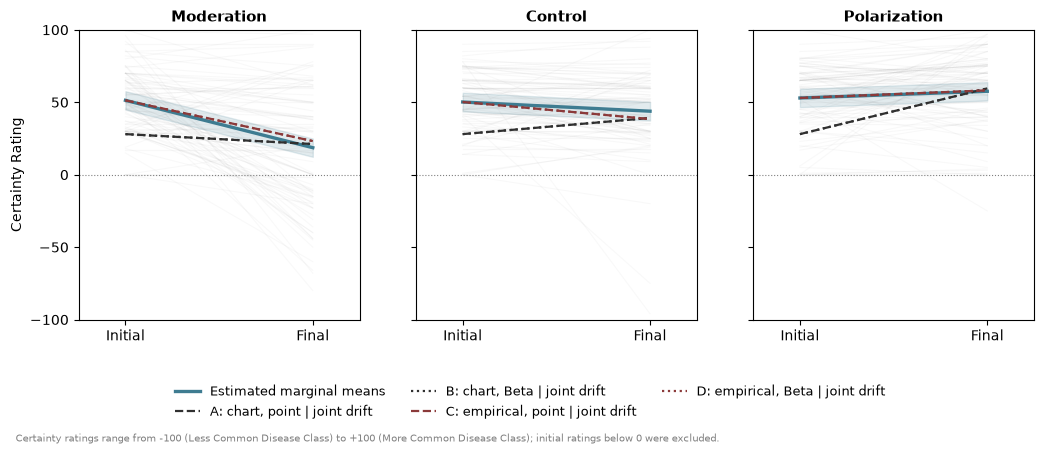

In [27]:
fig = plot_prepost([
    ("A: chart, point | joint drift", trajectory(fits[("joint", "A")]), "#303030", "--"),
    ("B: chart, Beta | joint drift", trajectory(fits[("joint", "B")]), "#303030", ":"),
    ("C: empirical, point | joint drift", trajectory(fits[("joint", "C")]), "#8B3A3A", "--"),
    ("D: empirical, Beta | joint drift", trajectory(fits[("joint", "D")]), "#8B3A3A", ":"),
])

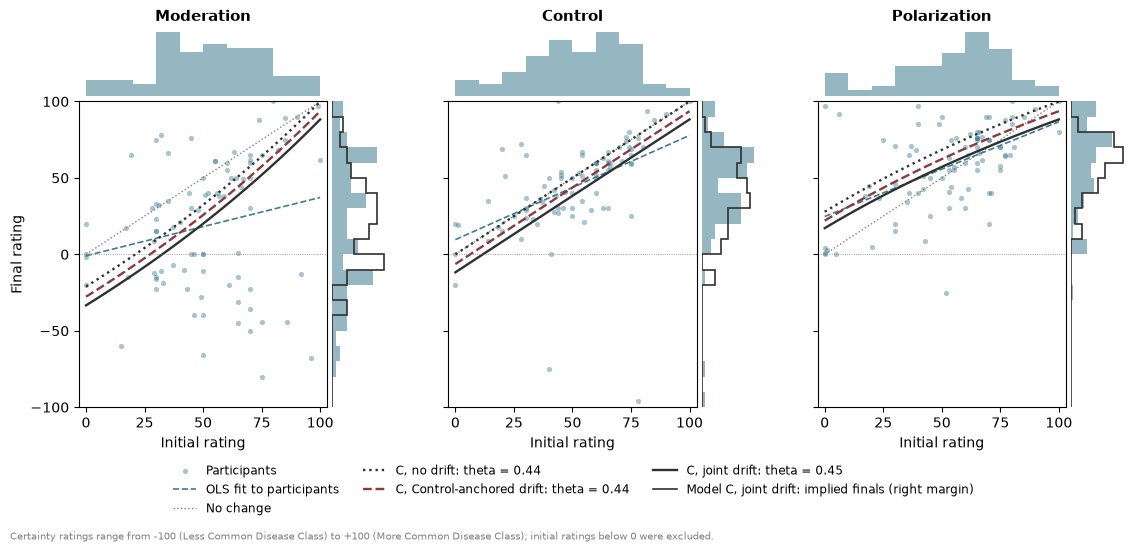

In [28]:
fig = plot_scatter([
    (f"C, no drift: theta = {fit_C['theta']:.2f}", curve_of(fit_C), "#303030", ":"),
    (f"C, Control-anchored drift: theta = {fits[('control', 'C')]['theta']:.2f}",
     curve_of(fits[("control", "C")]), "#8B3A3A", "--"),
    (f"C, joint drift: theta = {fits[('joint', 'C')]['theta']:.2f}",
     curve_of(fits[("joint", "C")]), "#303030", "-"),
], fits[("joint", "C")]["fitted"], "Model C, joint drift: implied finals (right margin)")

# Part 5: Interpretation

**Participants updated in the Bayesian direction.** Every fitted model
beats the no-update baseline by about 17 or more log-likelihood units:
the conflicting pair moved beliefs up in Polarization, down in
Moderation, and left Control flat, as the networks predict.

**A common response drift, not condition-specific reliability, explains
the Polarization/Moderation asymmetry.** This is the key comparison of
Part 4, and it is decisive. The two explanations each add one parameter
to Model C:

- condition-specific reliability (theta_P = 0.32, theta_M = 0.68):
  logLik -1251.2, AIC 2508.4;
- shared reliability plus drift (theta = 0.45, delta = -11.8):
  logLik -1245.6, AIC 2497.2.

Shared theta plus drift wins by 11 AIC points at equal parameter count,
and once delta is in the model the per-condition reliabilities coincide
(0.450 vs 0.440, LR = 0.02, p = 0.90). The validation is the more
compelling part: fixing delta at the value Control alone implies (-6.35, a
number that never saw a Polarization or Moderation rating) still beats the
condition-specific model (AIC 2503.2 vs 2508.4) and already removes most
of the split (LR 16.2 -> 3.4, p = 0.07). The asymmetry was an artifact of
an omitted downward process, exactly as the common sign of the residuals
suggested.

**Drift does not explain the conservatism.** With delta in the model the
shared reliability barely moves (0.438 -> 0.446; r from 0.78 to 0.80).
Participants' effective evidence weight is what it was; drift removes the
condition asymmetry, not the weakness of the updating. Those are two
separate findings.

**The jointly estimated drift is larger than Control's.** delta = -11.8
jointly against -6.4 in Control, so the Control-anchored validation is
conservative, and the drift model's residuals still tilt the same way
(Control over-shifted, Moderation under-shifted). Whether the extra shift
in the test conditions is a larger response drift there or something the
single-theta network misses cannot be decided from these data; the
per-condition test says it is not a reliability difference.

**Under the chart prior, "drift" is not drift.** With everyone started at
+28, the jointly estimated delta is *positive* (+11) — it repairs the
prior rather than modeling a downward shift — and the Control-anchored
delta leaves the chart models no better than no update at all (Control
predicted at 22 against an observed 44). The drift term is interpretable
only once the model starts each participant from their own rating. That
is the empirical prior's real contribution: without drift A and C were
within one log-likelihood unit of each other; with drift the prior choice
is what makes delta mean something.

**The reliability-prior axis stays empty, by design.** B equals A and D
equals C in every regime: with only conflicting test pairs, every theta
prior is observationally equivalent to some point mass through the single
ratio r, and drift, acting after the network, cannot break that. The
ridge does tell us two things: the point-mass estimate is a floor on mean
reliability beliefs, not an estimate of them — every equivalent Beta has
a higher mean, confined by the theta >= 0.25 constraint to a band of about
0.1 above the point mass — and an agreeing-tests condition would separate
point mass from uncertainty, which nothing in the present design can.

**What delta is, and is not.** It is a condition-independent response
shift between the two judgments: response-scale drift, anchoring or
compression, an order effect, or another systematic process. It is not a
belief-update parameter and should not yet be read as a genuine change in
disease belief. Control is what makes it detectable at all.

**What remains unexplained.** The envelope still leaves a large share of
participants outside anything the mean structure can produce, and
Moderation is still bimodal: one cluster barely moved, another flipped
below zero past the perfect-reliability limit, discarding the prior rather
than updating on it. Part 6 takes up test endorsement (the `Choice`
column); a participant-level drift is the other natural extension.

# Part 6: Two-stage model — endorse a test, then update on it

Every model above feeds *both* conflicting tests into the network. The
two-stage model says participants do something else. Screen 1 induces
their initial beliefs. On Screen 2 they see two conflicting tests and are
asked which one is more likely to be accurate; their answer is recorded in
`Choice` (1 = endorsed the individually more common disease of the pair —
Y1 over L1 in Polarization, L2 over Y2 in Moderation — and, in Control,
the test naming the more common class). They then report their updated
belief. The model has two stages:

- **Stage 1 (endorsement):** the participant chooses which test to believe.
- **Stage 2 (update):** they update on *only* the endorsed test; the
  unendorsed test is never entered as evidence, as if it had not been
  observed.

Stage 2 reuses the networks unchanged with evidence on a single test node.
Its structural consequence is large: with both tests, the theta -> 1 limit
leaves all mass on the two named diseases, one per class, so a Moderation
participant can never cross far below the midpoint; with one endorsed test,
theta -> 1 puts all mass on that disease, so an L2 endorser can be driven
toward -100 and a Y2 endorser toward +100. The model generates
Moderation's bimodality from `Choice`.

Stage 1 is modeled too, so that the two-stage model and Model C are
compared as generative models of the *pair* (Choice, Final) rather than
the two-stage model simply conditioning on more data. Under the network,
the posterior probability that the test naming disease d is the accurate
one, given both results, is p(d) theta (1-theta)/3 divided by the sum over
the two named diseases:

    P(endorse d_hi) = p(d_hi) / (p(d_hi) + p(d_lo)),

with theta cancelling; in Control it is P(C = H) = p(H), again theta-free.
Stage 1 therefore has no reliability parameter. It is given one lapse
parameter epsilon (a coin flip with probability epsilon), fitted by
maximum likelihood. Because the stage-1 term involves no model-specific
parameter, it is the same additive constant for every model in the
comparison; it is reported so the joint likelihood is explicit.

Control is included: its `Choice` picks a class, and the class-level
network with evidence on one test handles it directly. That also means
Control now predicts Bayesian movement (toward the endorsed class), so the
Control-anchored drift is the mean Control *residual* of the two-stage
prediction rather than the mean raw change.

## Stage 2: update on the endorsed test

In [29]:
from scipy.special import expit, logit

## Test pair per condition, ordered (individually more common, less common);
## Choice = 1 endorses the first. Control's tests name classes.
PAIR = {"Polarization": ("Y1", "L1"), "Moderation": ("L2", "Y2"), "Control": ("H", "A")}
ENDORSED = {cond: {1: hi, 0: lo} for cond, (hi, lo) in PAIR.items()}


def final_belief_chosen(condition, prior_D, theta_prior, endorsed):
    """P(C = H | T1 = endorsed): the network with the endorsed test as its only evidence."""
    make_network, _ = NETWORKS[condition]
    grid, weights = theta_prior
    infer = VariableElimination(make_network(prior_D, grid, weights))
    return float(_query(infer, ["C"], {"T1": endorsed}).get_value(C="H"))


def stage2_predictions(theta_prior, data):
    """Two-stage predicted final rating (slider scale) for each row of data:
    the participant's own prior, updated on the test they endorsed."""
    keys = list(zip(data["Condition"], data["Initial"], data["Choice"]))
    cache = {}
    for key in set(keys):
        cond, initial, choice = key
        prior_D = prior_D_for("empirical", initial)
        cache[key] = float(to_slider(final_belief_chosen(
            cond, prior_D, theta_prior, ENDORSED[cond][int(choice)])))
    return np.array([cache[k] for k in keys])

## Stage 1: endorsement

Observed endorsement rates against the normative probability under each
participant's own prior, and the fitted lapse rate.

In [30]:
def endorsement_probability(data):
    """Normative P(Choice = 1) under each participant's own prior; theta cancels."""
    out = []
    for cond, initial in zip(data["Condition"], data["Initial"]):
        p = prior_D_for("empirical", initial)
        hi, lo = PAIR[cond]
        out.append(p["Y1"] + p["Y2"] if cond == "Control" else p[hi] / (p[hi] + p[lo]))
    return np.array(out)


def choice_loglik(epsilon, data):
    p = (1 - epsilon) * endorsement_probability(data) + epsilon / 2
    p = np.clip(p, 1e-12, 1 - 1e-12)  ## an initial of 100 gives the A-class zero prior mass
    c = data["Choice"].to_numpy()
    return float(np.sum(c * np.log(p) + (1 - c) * np.log(1 - p)))


stage1 = minimize_scalar(lambda e: -choice_loglik(e, obs), bounds=(0, 1), method="bounded")
EPSILON_HAT = float(stage1.x)
STAGE1_LOGLIK = -float(stage1.fun)
print(f"Stage 1: lapse epsilon = {EPSILON_HAT:.3f}, choice logLik = {STAGE1_LOGLIK:.2f} "
      f"(normative without lapse: {choice_loglik(0.0, obs):.2f}; coin flip: {choice_loglik(1.0, obs):.2f})")
print(obs.assign(p_norm=endorsement_probability(obs),
                 p_fit=(1 - EPSILON_HAT) * endorsement_probability(obs) + EPSILON_HAT / 2)
         .groupby("Condition")[["Choice", "p_norm", "p_fit"]].mean().round(3)
         .rename(columns={"Choice": "observed rate", "p_norm": "normative", "p_fit": "with lapse"}))

Stage 1: lapse epsilon = 0.170, choice logLik = -126.96 (normative without lapse: -162.40; coin flip: -173.98)
              observed rate  normative  with lapse
Condition                                         
Control               0.866      0.751       0.708
Moderation            0.553      0.433       0.445
Polarization          0.917      0.985       0.902


## Fitting

Shared sigma throughout. theta is either one population value or one per
condition (all three conditions are informative now, since Control's
endorsed test moves belief). Drift regimes as in Part 4: none,
Control-anchored (delta = mean Control residual of the two-stage
prediction, profiled at each theta), or joint (delta = mean residual over
everyone). With no drift the per-condition fit separates by condition;
with drift the three thetas are optimized together.

In [31]:
TS_CONDS = ["Polarization", "Moderation", "Control"]


def evaluate_ts(preds, data, regime):
    if regime == "control":
        in_control = (data["Condition"] == "Control").to_numpy()
        delta = float(np.mean(data["Final"].to_numpy()[in_control] - preds[in_control]))
        return evaluate(preds, data, delta)
    return evaluate(preds, data, regime)  ## None or "joint"


def _preds_by_condition(thetas, data):
    out = np.empty(len(data))
    for cond, theta in thetas.items():
        mask = (data["Condition"] == cond).to_numpy()
        if mask.any():
            out[mask] = stage2_predictions(point_mass_prior(theta), data[mask])
    return out


def fit_two_stage(regime=None, per_condition=False, data=None):
    data = obs if data is None else data
    bounds = (THETA_FLOOR, 0.999)
    if not per_condition:
        res = minimize_scalar(
            lambda t: -evaluate_ts(stage2_predictions(point_mass_prior(t), data), data, regime)["logLik"],
            bounds=bounds, method="bounded", options={"xatol": 1e-6})
        thetas = {c: float(res.x) for c in TS_CONDS}
        k_theta = 1
    elif regime is None:  ## total SSE is additive over conditions: fit each alone
        thetas = {}
        for cond in TS_CONDS:
            sub = data[data["Condition"] == cond]
            res = minimize_scalar(
                lambda t, sub=sub: -evaluate(stage2_predictions(point_mass_prior(t), sub), sub)["logLik"],
                bounds=bounds, method="bounded", options={"xatol": 1e-6})
            thetas[cond] = float(res.x)
        k_theta = 3
    else:  ## drift couples the conditions: optimize the three thetas together
        to_theta = lambda x: bounds[0] + (bounds[1] - bounds[0]) * expit(x)
        res = minimize(
            lambda x: -evaluate_ts(_preds_by_condition(dict(zip(TS_CONDS, to_theta(x))), data),
                                   data, regime)["logLik"],
            np.zeros(3), method="Nelder-Mead",
            options={"xatol": 1e-3, "fatol": 1e-4, "maxiter": 300})
        thetas = dict(zip(TS_CONDS, map(float, to_theta(res.x))))
        k_theta = 3
    preds = _preds_by_condition(thetas, data)
    ev = evaluate_ts(preds, data, regime)
    return {"family": "two-stage", "prior": "empirical", "thetas": thetas,
            "theta": thetas["Polarization"] if not per_condition else None,
            "preds": preds, "n_params": k_theta + 1 + (0 if regime is None else 1), **ev}


def describe_ts(fit):
    th = fit["thetas"]
    est = (f"theta = {fit['theta']:.4f}" if fit["theta"] is not None
           else ", ".join(f"{c[:3]} {v:.3f}" for c, v in th.items()))
    if fit["delta"] is not None:
        est += f", delta = {fit['delta']:.2f}"
    return est


ts = {}
for regime in [None, "control", "joint"]:
    for per_cond in [False, True]:
        ts[(regime, per_cond)] = fit_two_stage(regime, per_cond)
        print(f"two-stage | {REGIME_LABEL[regime or 'none']:<22} | "
              f"{'per-condition' if per_cond else 'shared'} theta: "
              f"{describe_ts(ts[(regime, per_cond)])}, sigma = {ts[(regime, per_cond)]['sigma']:.2f}, "
              f"logLik = {ts[(regime, per_cond)]['logLik']:.2f}")

two-stage | no drift               | shared theta: theta = 0.3691, sigma = 36.94, logLik = -1262.07


two-stage | no drift               | per-condition theta: Pol 0.333, Mod 0.443, Con 0.250, sigma = 35.88, logLik = -1254.77


two-stage | Control-anchored drift | shared theta: theta = 0.4010, delta = -15.17, sigma = 33.66, logLik = -1238.76


two-stage | Control-anchored drift | per-condition theta: Pol 0.492, Mod 0.384, Con 0.405, delta = -15.36, sigma = 33.38, logLik = -1236.62


two-stage | joint drift            | shared theta: theta = 0.3998, delta = -15.53, sigma = 33.66, logLik = -1238.74


two-stage | joint drift            | per-condition theta: Pol 0.529, Mod 0.372, Con 0.372, delta = -18.60, sigma = 33.17, logLik = -1235.08


## Comparison

All 251 participants. `logLik` is the Final-rating likelihood as in the
earlier tables; `joint logLik` adds the common stage-1 term, which shifts
every row equally. Model C rows are the Part 4 fits.

In [32]:
entries = [("Null: no update (final = initial)", fit_null, "-")]
for regime in ["none", "control", "joint"]:
    f = fits[(regime, "C")]
    entries.append((f"C: both tests | {REGIME_LABEL[regime]}", f, describe(f)))
for regime in [None, "control", "joint"]:
    for per_cond in [False, True]:
        f = ts[(regime, per_cond)]
        entries.append((f"Two-stage: {'per-condition' if per_cond else 'shared'} theta | "
                        f"{REGIME_LABEL[regime or 'none']}", f, describe_ts(f)))
table_ts = summary_table(entries)
table_ts.insert(table_ts.columns.get_loc("logLik") + 1, "joint logLik", table_ts["logLik"] + STAGE1_LOGLIK)
print(table_ts.round(2).to_string())

best_ts = ts[("joint", False)]
print("\nResidual SD by condition, two-stage + joint drift (shared theta):")
print(obs.assign(resid=obs["Final"] - best_ts["fitted"]).groupby("Condition")["resid"].std().round(2))

                                                                                                Estimate  k  sigma   logLik  joint logLik      AIC      BIC   dAIC
Model                                                                                                                                                             
Null: no update (final = initial)                                                                      -  1  39.12 -1276.49      -1403.45  2554.97  2558.50  74.80
C: both tests | no drift                                                                  theta = 0.4384  2  36.53 -1259.29      -1386.25  2522.58  2529.63  42.41
C: both tests | Control-anchored drift                                     theta = 0.4424, delta = -6.35  3  35.01 -1248.60      -1375.56  2503.20  2513.78  23.04
C: both tests | joint drift                                               theta = 0.4459, delta = -11.76  3  34.59 -1245.58      -1372.54  2497.15  2507.73  16.99
Two-stage: shared thet

## Reachable envelope

With one endorsed test the reachable interval runs from the no-update
value (theta = 0.25) to the endorsed disease's class (theta -> 1), shifted
by any drift. A participant is outside it only by moving *against* their
own endorsement. Counts for Model C under the same drift are shown for
reference.

In [33]:
def envelope_two_stage(delta=None):
    rows = []
    for cond in cond_order:
        sub = obs[obs["Condition"] == cond]
        below = above = 0
        cache = {}
        for initial, final, choice in zip(sub["Initial"], sub["Final"], sub["Choice"]):
            key = (initial, choice)
            if key not in cache:
                prior_D = empirical_prior(float(from_slider(initial)))
                cache[key] = np.array([
                    to_slider(final_belief_chosen(cond, prior_D, point_mass_prior(t),
                                                  ENDORSED[cond][int(choice)]))
                    for t in (THETA_FLOOR, 1 - 1e-9)])
            reach = cache[key] + (0 if delta is None else delta)
            below += final < reach.min() - 1e-9
            above += final > reach.max() + 1e-9
        rows.append({"Condition": cond, "n": len(sub), "outside": below + above,
                     "share": (below + above) / len(sub), "below": below, "above": above})
    return pd.DataFrame(rows).set_index("Condition")


for label, delta in [("no drift", None), ("joint drift", best_ts["delta"])]:
    print(f"{label}: two-stage envelope")
    print(envelope_two_stage(delta).round(2).to_string())
    print(f"{label}: Model C envelope (delta = {fits[('joint', 'C')]['delta'] if delta is not None else 'none'})")
    print(envelope_counts(None if delta is None else fits[("joint", "C")]["delta"]).round(2).to_string())
    print()

no drift: two-stage envelope
               n  outside  share  below  above
Condition                                     
Moderation    85       37   0.44     28      9
Control       82       43   0.52     39      4
Polarization  84       27   0.32     24      3
no drift: Model C envelope (delta = none)
               n  outside  share  below  above
Condition                                     
Polarization  84       32   0.38     29      3
Moderation    85       45   0.53     30     15

joint drift: two-stage envelope
               n  outside  share  below  above
Condition                                     
Moderation    85       30   0.35     14     16
Control       82       25   0.30     13     12
Polarization  84       27   0.32      9     18
joint drift: Model C envelope (delta = -11.760657627130975)
               n  outside  share  below  above
Condition                                     
Polarization  84       32   0.38     19     13
Moderation    85       52   0.61     

## Figures

Pre/post trajectories (both models with joint drift), and each
participant's final against their initial, coloured by which test they
endorsed, with the two-stage curve for each endorsement.

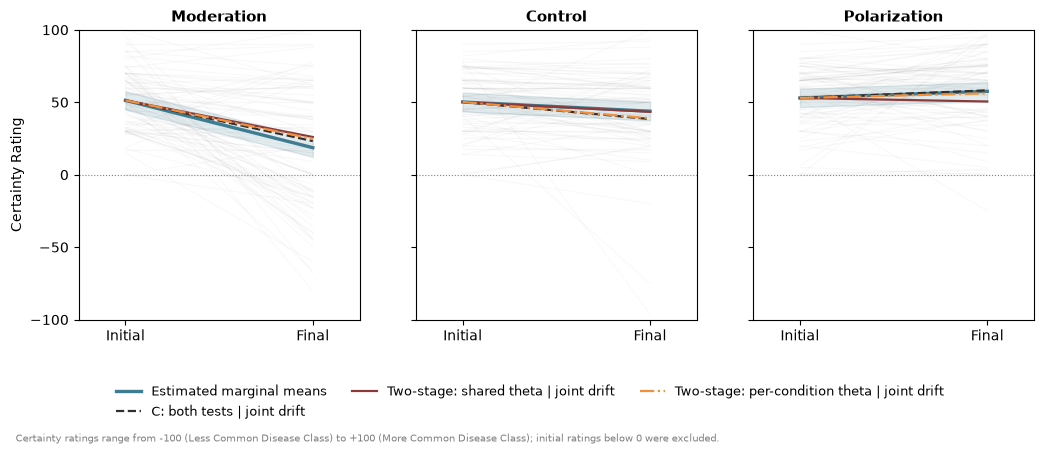

In [34]:
fig = plot_prepost([
    ("C: both tests | joint drift", trajectory(fits[("joint", "C")]), "#303030", "--"),
    ("Two-stage: shared theta | joint drift", trajectory(ts[("joint", False)]), "#8B3A3A", "-"),
    ("Two-stage: per-condition theta | joint drift", trajectory(ts[("joint", True)]), "#F28F3B", "-."),
])

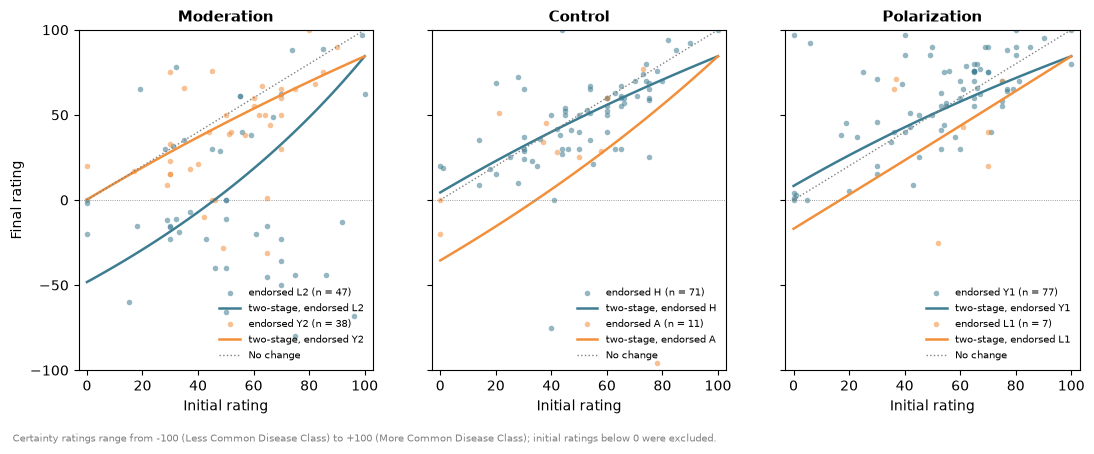

In [35]:
def plot_scatter_by_choice(fit):
    colors = {1: "#3E7C91", 0: "#F28F3B"}
    fig, axes = plt.subplots(1, 3, figsize=(11, 4.6), sharey=True)
    for ax, cond in zip(axes, cond_order):
        sub = obs[obs["Condition"] == cond]
        hi, lo = PAIR[cond]
        for choice, name in [(1, hi), (0, lo)]:
            pts = sub[sub["Choice"] == choice]
            ax.scatter(pts["Initial"], pts["Final"], s=16, color=colors[choice], alpha=0.55,
                       linewidths=0, label=f"endorsed {name} (n = {len(pts)})")
            grid_data = pd.DataFrame({"Condition": cond, "Initial": initial_grid, "Choice": choice})
            curve = stage2_predictions(point_mass_prior(fit["thetas"][cond]), grid_data)
            if fit["delta"] is not None:
                curve = curve + fit["delta"]
            ax.plot(initial_grid, curve, color=colors[choice], lw=1.8,
                    label=f"two-stage, endorsed {name}")
        ax.plot([0, 100], [0, 100], ls=":", color="gray", lw=1, label="No change")
        ax.axhline(0, ls=":", color="gray", lw=0.6)
        ax.set_title(cond, fontweight="bold", fontsize=11)
        ax.set_xlim(-3, 103)
        ax.set_xlabel("Initial rating")
        ax.legend(fontsize=7.5, frameon=False, loc="lower right")
    axes[0].set_ylim(-100, 100)
    axes[0].set_yticks(range(-100, 101, 50))
    axes[0].set_ylabel("Final rating")
    fig.text(0.01, 0.005, SCALE_CAPTION, fontsize=7.5, color="gray")
    fig.subplots_adjust(bottom=0.16, left=0.07, right=0.98, top=0.9)
    return fig


fig = plot_scatter_by_choice(ts[("joint", False)])

## Interpretation

**Stage 1: endorsements track the normative posterior, with a tilt.** The
probability of endorsing the individually more common option under each
participant's own prior orders the conditions correctly (Polarization near
certainty, Moderation near a coin flip, Control in between), but observed
rates sit above it in Moderation (0.55 vs 0.43) and especially Control
(0.87 vs 0.75): participants lean toward the more common option beyond
what their initial ratings imply. A lapse rate of about 0.17 is needed,
partly because some endorsements are impossible under a literal reading of
the initial rating (an initial of 100 leaves no mass on the A class). The
stage-1 term carries no reliability parameter and is common to every
model, so it does not affect the ranking below.

**Stage 2 without drift is no better than Model C.** Updating on a single
endorsed test at theta near 0.37 predicts substantial movement toward the
endorsed class, and many participants moved the other way — Control's
H-endorsers fell, and Moderation's Y2-endorsers fell despite endorsing an
H-class disease. Without a drift term the two-stage model has no way to
absorb that and pays for it (logLik -1262 vs -1259).

**With drift, the two-stage model is the best account in the notebook.**
Two-stage plus joint drift (theta = 0.40, delta = -15.5) beats Model C
plus joint drift by 7 log-likelihood units at equal parameter count
(AIC 2483.5 vs 2497.2). The decisive evidence is the validation: under the
two-stage model, the drift estimated from Control alone (-15.2, the mean
Control residual after the endorsed-test update) is essentially the joint
estimate (-15.5). Under Model C the Control-anchored value (-6.4) was only
half the joint one (-11.8). The two-stage model makes Control's raw change
interpretable: its 87% H-endorsers are predicted to move up by about 9
points and instead fell by 4, a residual of -15 that matches the drift in
the test conditions. One common drift really is common once endorsement
is in the model, and a drift that never saw a Polarization or Moderation
rating leaves the two-stage model 20 AIC points ahead of Model C anchored
the same way.

**Condition-specific reliability is weak at best.** Per-condition theta
under joint drift (Polarization 0.53, Moderation 0.37, Control 0.37)
improves the likelihood by 3.7 units for two extra parameters (LR = 7.3
on 2 df, p = 0.03): AIC prefers it by 3, BIC prefers the shared theta.
The Part 2 pattern of Moderation demanding a much stronger reliability is
gone — if anything reversed. The shared-theta, joint-drift model is the
defensible main model.

**What endorsement buys, and what it does not.** The envelope shows the
structural gain: under joint drift the share of Moderation participants
outside the reachable set falls from 61% (Model C) to 35%, because the
flipped cluster is now reachable. But residual SDs remain very uneven
(Polarization 23, Control 29, Moderation 44): within Moderation's
endorsement groups there is still a great deal the mean structure does not
explain, above all the Y2 endorsers who fell anyway. Two extensions
follow naturally. A condition-specific noise SD would make that
heterogeneity part of the model rather than a diagnostic (it is what the
separate-sigma fit on the Polarization-Moderation subset was picking up).
And the hard "unendorsed test is discarded" assumption could be softened
to a weight on the unendorsed test, which nests Model C (weight 1) and the
two-stage model (weight 0) and would let the data locate itself between
them.